# Exploratory Data Anlysis on CFBA Compliant Dataset

## Import Libraries

In [ ]:
import pandas as pd
import matplotlib as plt

import re # For Regular Expressions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import nltk

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
import sys
import os
sys.path.append(os.path.abspath('../'))
from src.eda_utils import (
    set_aesthetics,
    load_data,
    assess_quality,
    clean_text_noise,
    normalize_text
)

Matplotlib is building the font cache; this may take a moment.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dagic\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Load Dataset and explore

In [5]:
df_raw = load_data('../data/raw/complaints.csv')
df_raw.head(3)

Loading data from: ../data/raw/complaints.csv


c:\Users\dagic\OneDrive\Documents\KAIM\Week_7\rag-complaint-chatbot\src\eda_utils.py:35: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Shape  : 9,609,797 rows × 18 columns
Memory : 13284.4 MB


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689


In [7]:
df_raw.describe()

,Complaint ID
count,9.609797e+06
mean,8.092744e+06
std,3.774842e+06
min,1.000000e+00
25%,5.038016e+06
50%,8.448508e+06
75%,1.129591e+07
max,1.423259e+07


In [9]:
df_raw.dtypes

Date received                     str
Product                           str
Sub-product                       str
Issue                             str
Sub-issue                         str
Consumer complaint narrative      str
Company public response           str
Company                           str
State                             str
ZIP code                          str
Tags                              str
Consumer consent provided?        str
Submitted via                     str
Date sent to company              str
Company response to consumer      str
Timely response?                  str
Consumer disputed?                str
Complaint ID                    int64
dtype: object

In [ ]:
# --- EDA: Distribution of Products ---
print("\n--- EDA: Product Distribution ---")
print(df_raw['Product'].value_counts())


--- EDA: Product Distribution ---
Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                      

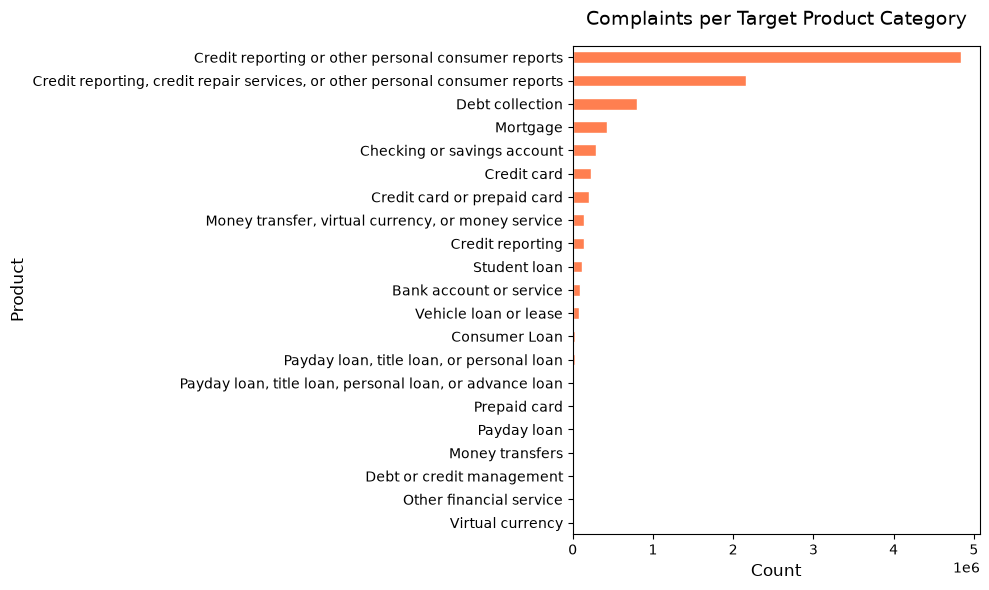

In [28]:
# 1. Reverse the order so the largest bar is at the top
data = df_raw['Product'].value_counts()

# 2. Increase height dynamically or set a taller figure size
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Use kind='barh'
data.plot(kind='barh', ax=ax, color='coral', edgecolor='white')

ax.set_title('Complaints per Target Product Category', fontsize=14, pad=15)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Product', fontsize=12)

# 4. Invert the y-axis so the highest count is on top
ax.invert_yaxis()  

# 5. Automatically adjust padding so labels aren't cut off
plt.tight_layout()
plt.savefig('../data/processed/filtered_product_dist.png', dpi=120)
plt.show()

In [13]:
# --- EDA: Calculate and visualize word count (simple for demo) ---
df_raw['word_count'] = df_raw['Issue'].apply(lambda x: len(str(x).split()) if str(x).strip() else 0)
print("\n--- EDA: Word Count Distribution ---")
print(df_raw['word_count'].describe())


--- EDA: Word Count Distribution ---
count    9.609797e+06
mean     5.709747e+00
std      2.074828e+00
min      1.000000e+00
25%      5.000000e+00
50%      5.000000e+00
75%      6.000000e+00
max      1.600000e+01
Name: word_count, dtype: float64


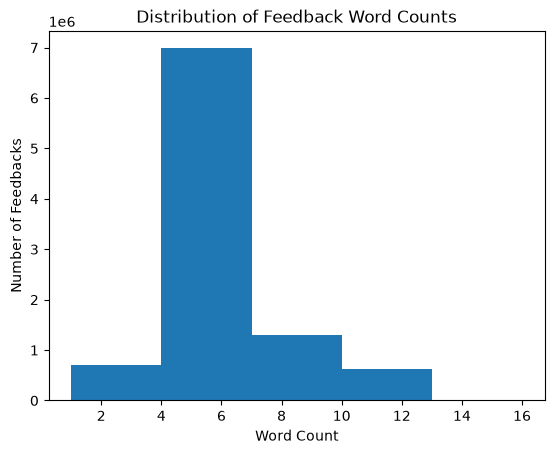

In [14]:
import matplotlib.pyplot as plt
plt.hist(df_raw['word_count'], bins=5)
plt.title('Distribution of Feedback Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Number of Feedbacks')
plt.show()

With narrative:    2,980,756 (31.0%)
Without narrative: 6,629,041 (69.0%)


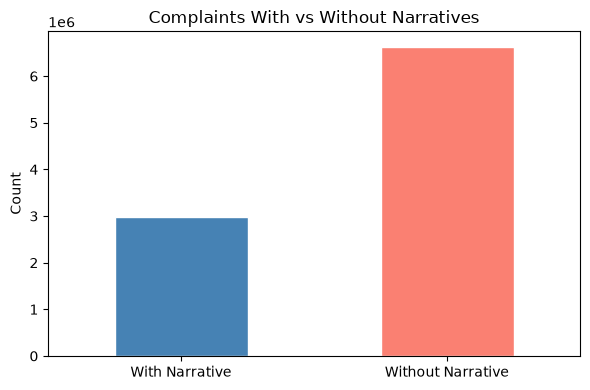

In [24]:
# Narratives: present vs absent
narrative_col = 'Consumer complaint narrative'
has_narrative = df_raw[narrative_col].notna() & (df_raw[narrative_col].astype(str).str.strip() != '')
print(f'With narrative:    {has_narrative.sum():>8,} ({has_narrative.mean():.1%})')
print(f'Without narrative: {(~has_narrative).sum():>8,} ({(~has_narrative).mean():.1%})')

fig, ax = plt.subplots(figsize=(6, 4))
pd.Series({'With Narrative': has_narrative.sum(), 'Without Narrative': (~has_narrative).sum()}).plot(
    kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='white'
)
ax.set_title('Complaints With vs Without Narratives')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/narrative_availability.png', dpi=120)
plt.show()

count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
Name: Consumer complaint narrative, dtype: float64


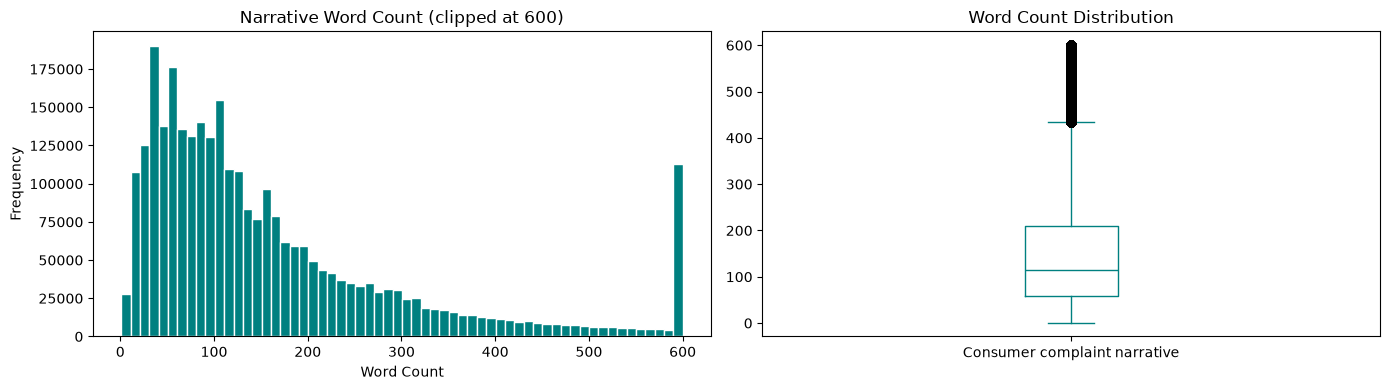

In [25]:
# Narrative word-count distribution (on records that have narratives)
word_counts = df_raw.loc[has_narrative, narrative_col].str.split().str.len()
print(word_counts.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
word_counts.clip(upper=600).plot(kind='hist', bins=60, ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Narrative Word Count (clipped at 600)')
axes[0].set_xlabel('Word Count')

word_counts.clip(upper=600).plot(kind='box', ax=axes[1], color='teal')
axes[1].set_title('Word Count Distribution')
plt.tight_layout()
plt.savefig('../data/processed/narrative_wordcount.png', dpi=120)
plt.show()

## Preprocessing

In [15]:
assess_quality(df_raw)


Columns with missing values:


,missing_count,missing_%
Sub-product,235295,2.4485
Issue,6,0.0001
Sub-issue,839522,8.7361
Consumer complaint narrative,6629041,68.9821
Company public response,4770207,49.6390
State,54516,0.5673
ZIP code,30228,0.3146
Tags,8981029,93.4570
Consumer consent provided?,1649561,17.1654
Company response to consumer,20,0.0002


In [17]:
print("\n--- Preprocessing: Removing Empty Feedback ---")
df_cleaned = df_raw[df_raw['Issue'].str.strip() != ''].copy()
print(f"Original rows: {len(df_raw)}, Rows after removing empty: {len(df_cleaned)}")
print(df_cleaned[['Complaint ID', 'Issue']])


--- Preprocessing: Removing Empty Feedback ---
Original rows: 9609797, Rows after removing empty: 9609797
         Complaint ID                                              Issue
0            14195687               Incorrect information on your report
1            14195688                  Attempts to collect debt not owed
2            14195689                        Improper use of your report
3            14195690                        Improper use of your report
4            14195692               Incorrect information on your report
...               ...                                                ...
9609792       2102374           Unable to get credit report/credit score
9609793       5637858  Problem with a credit reporting company's inve...
9609794       2012835           Unable to get credit report/credit score
9609795        740118                   Improper use of my credit report
9609796       1110751             Incorrect information on credit report

[9609797 rows x 

In [21]:
# 1. Apply the refined cleaning to df_cleaned
df_cleaned['processed_Issue'] = df_cleaned['Issue'].apply(clean_text_noise)

# 2. Calculate length using df_cleaned, NOT df_raw
df_cleaned['clean_length'] = df_cleaned['processed_Issue'].apply(lambda x: len(str(x).split()))

# 3. Filter the rows on df_cleaned directly
df_cleaned = df_cleaned[df_cleaned['clean_length'] > 2]

# Preview the results
print(df_cleaned[['Issue', 'processed_Issue']].head())

                                  Issue                       processed_Issue
0  Incorrect information on your report  incorrect information on your report
1     Attempts to collect debt not owed     attempts to collect debt not owed
2           Improper use of your report           improper use of your report
3           Improper use of your report           improper use of your report
4  Incorrect information on your report  incorrect information on your report


In [45]:
# 1. Capture all distinct raw variations to avoid dropping rows
raw_target_products = [
    'Credit card or prepaid card', 
    'Credit card', 
    'Payday loan, title loan, or personal loan', 
    'Checking or savings account', 
    'Money transfer, virtual currency, or money service'
]

df_filtered = df_cleaned[df_cleaned['Product'].isin(raw_target_products)].copy()

# 2. Define the consolidation mapping
product_merger = {
    'Credit card or prepaid card': 'Credit Card',
    'Credit card': 'Credit Card',
    'Payday loan, title loan, or personal loan': 'Personal Loan',
    'Checking or savings account': 'Savings Account',
    'Money transfer, virtual currency, or money service': 'Money Transfer'
}

# 3. Merge the categories together
df_filtered['Product'] = df_filtered['Product'].map(product_merger)

# Verify the merge
print("Consolidated Categories:")
print(df_filtered['Product'].value_counts())

Consolidated Categories:
Product
Credit Card        373454
Savings Account    291173
Money Transfer     145066
Personal Loan       30641
Name: count, dtype: int64


In [46]:
df_filtered.shape

(840334, 23)

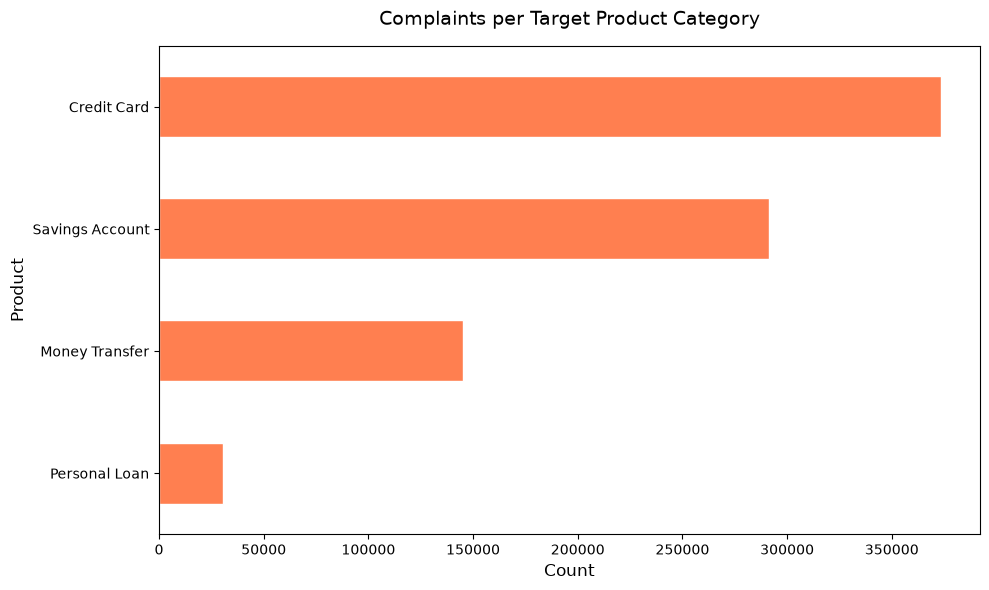

In [47]:
counts = df_filtered['Product'].value_counts()

if counts.empty:
    print("⚠️ Plotting skipped: df_filtered['Product'] has no data! Check your filtering steps above.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Using the horizontal 'barh' layout to keep long text labels clean!
    counts.plot(kind='barh', ax=ax, color='coral', edgecolor='white')
    
    ax.set_title('Complaints per Target Product Category', fontsize=14, pad=15)
    ax.set_xlabel('Count', fontsize=12)
    ax.set_ylabel('Product', fontsize=12)
    ax.invert_yaxis()  # Puts highest count on top
    
    plt.tight_layout()
    plt.savefig('../data/processed/filtered_product_dist.png', dpi=120)
    plt.show()

## Stop word removal and Lemmatization

In [48]:
# Run it again and watch "delayed" -> "delay" and "crashing" -> "crash"
df_filtered['normalized_Issue'] = df_filtered['processed_Issue'].apply(normalize_text)
print(df_filtered[['processed_Issue', 'normalized_Issue']])

                                           processed_Issue  \
334      problem with a companys investigation into an ...   
351                                    managing an account   
437                                     closing an account   
595      problem with a companys investigation into an ...   
661      problem with a companys investigation into an ...   
...                                                    ...   
9609730            credit card protection  debt protection   
9609735                                managing an account   
9609739                       problem when making payments   
9609743        vehicle was repossessed or sold the vehicle   
9609769    problem with a purchase shown on your statement   

                                    normalized_Issue  
334      problem company investigation exist problem  
351                                   manage account  
437                                    close account  
595      problem company investigat

## Final Cleaned Dataset

In [49]:
print("\n--- Final Cleaned & Normalized Data ---")
print(df_filtered[['Complaint ID', 'Product', 'Issue', 'processed_Issue', 'normalized_Issue','Consumer complaint narrative']])


--- Final Cleaned & Normalized Data ---
         Complaint ID          Product  \
334          14196294      Credit Card   
351          13984551  Savings Account   
437          13956296  Savings Account   
595          14196854      Credit Card   
661          14196870      Credit Card   
...               ...              ...   
9609730       1318092      Credit Card   
9609735       6238646  Savings Account   
9609739       6237456      Credit Card   
9609743       6238123    Personal Loan   
9609769       5817410      Credit Card   

                                                     Issue  \
334      Problem with a company's investigation into an...   
351                                    Managing an account   
437                                     Closing an account   
595      Problem with a company's investigation into an...   
661      Problem with a company's investigation into an...   
...                                                    ...   
9609730           Cr

In [50]:
from pathlib import Path
output = Path('../data/processed/filtered_complaints.csv')
output.parent.mkdir(parents=True, exist_ok=True)
df_filtered.to_csv(output, index=False)
print('saved to', output)

saved to ..\data\processed\filtered_complaints.csv


# Conclusion

    -   The initial Consumer Financial Protection Bureau (CFPB) dataset contains millions of multi-industry records. A significant portion lacks narrative data (69%), containing only structured categorical classifications.

    